In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve
)
from sklearn.preprocessing import StandardScaler

# 1. Preparação dos dados
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

feature_groups = ["mean", "se", "worst"]
base_features = [
    "radius", "texture", "perimeter", "area", "smoothness",
    "compactness", "concavity", "concave_points", "symmetry",
    "fractal_dimension"
]
feature_cols = [f"{b}_{g}" for g in feature_groups for b in base_features]
cols = ["id", "diagnosis"] + feature_cols

df = pd.read_csv(DATA_URL, header=None, names=cols)

# Conversão de diagnosis: M = 1 (maligno), B = 0 (benigno)
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Separando x e y
X = df[feature_cols]
y = df["diagnosis"]

# Padronização dos atributos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Divisão em treino (70%) e teste (30%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)


Acurácia: 0.977
Precisão: 0.984
Recall: 0.953
F1-score: 0.968



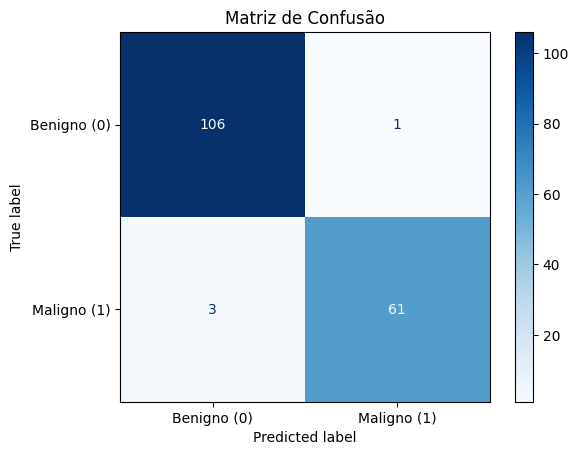

In [2]:
# 2. Treinamento do modelo
model = LogisticRegression(max_iter=500, solver='liblinear')
model.fit(X_train, y_train)

# Predição e avaliação
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Acurácia: {acc:.3f}")
print(f"Precisão: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"F1-score: {f1:.3f}\n")

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Benigno (0)", "Maligno (1)"]).plot(cmap="Blues")
plt.title("Matriz de Confusão")
plt.show()
print("\n")


Top 10 variáveis mais influentes:

               Variável  Coeficiente  Valor_Absoluto
21        texture_worst     1.362210        1.362210
10            radius_se     1.235548        1.235548
28       symmetry_worst     1.061038        1.061038
13              area_se     0.921562        0.921562
23           area_worst     0.914994        0.914994
15       compactness_se    -0.904826        0.904826
7   concave_points_mean     0.860938        0.860938
20         radius_worst     0.847005        0.847005
6        concavity_mean     0.833038        0.833038
26      concavity_worst     0.823596        0.823596


/tmp/ipython-input-4197554193.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef.head(15), y="Variável", x="Coeficiente", palette="coolwarm")


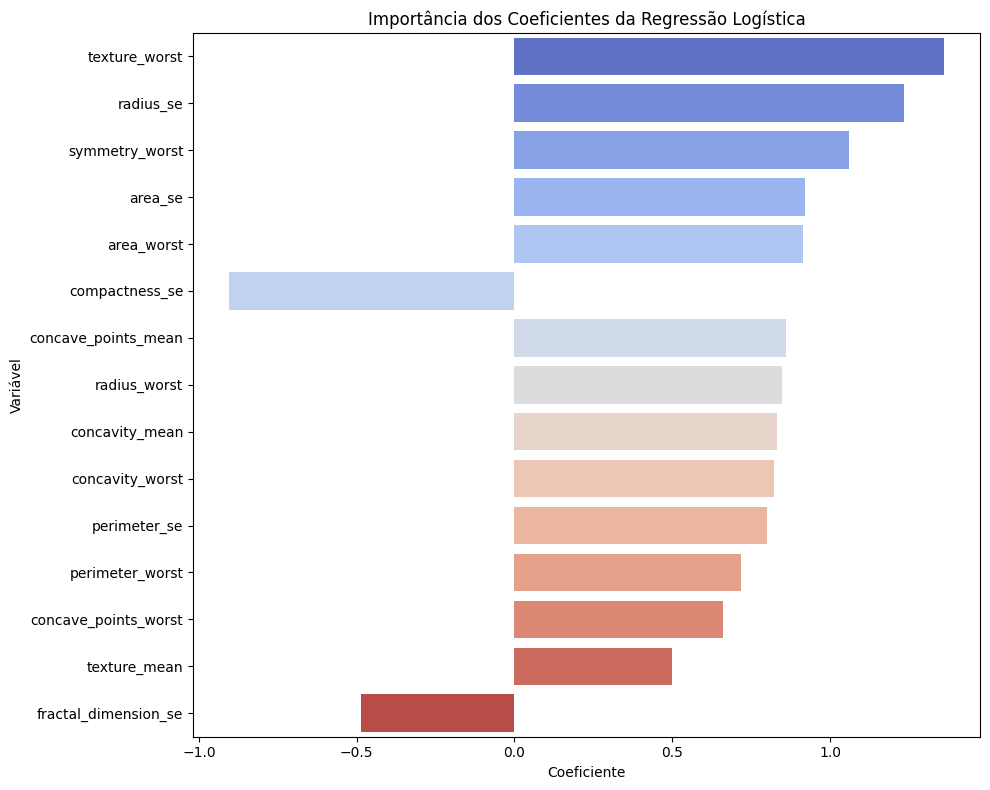

In [3]:
# 3. Interpretação dos coeficientes
coef = pd.DataFrame({
    "Variável": feature_cols,
    "Coeficiente": model.coef_[0],
    "Valor_Absoluto": np.abs(model.coef_[0])
}).sort_values(by="Valor_Absoluto", ascending=False)

print("Top 10 variáveis mais influentes:\n")
print(coef.head(10))

# Gráfico dos coeficientes
plt.figure(figsize=(10,8))
sns.barplot(data=coef.head(15), y="Variável", x="Coeficiente", palette="coolwarm")
plt.title("Importância dos Coeficientes da Regressão Logística")
plt.tight_layout()
plt.show()
print("\n")


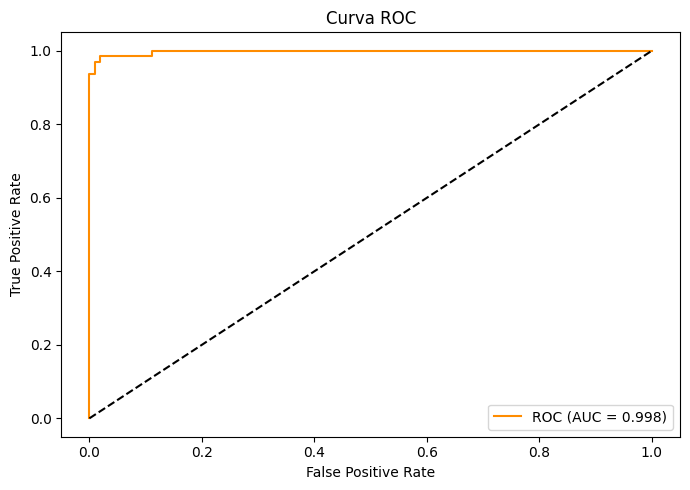

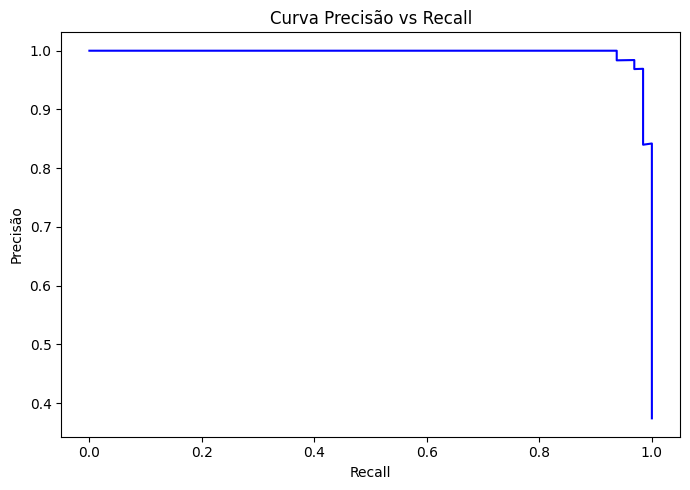

In [4]:
# 4. Visualizações adicionais

# a) Curva ROC e AUC
y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})", color="darkorange")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.tight_layout()
plt.show()
print("\n")

# b) Curva Precisão vs Recall
precisions, recalls, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(7,5))
plt.plot(recalls, precisions, color="blue")
plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.title("Curva Precisão vs Recall")
plt.tight_layout()
plt.show()
print("\n")


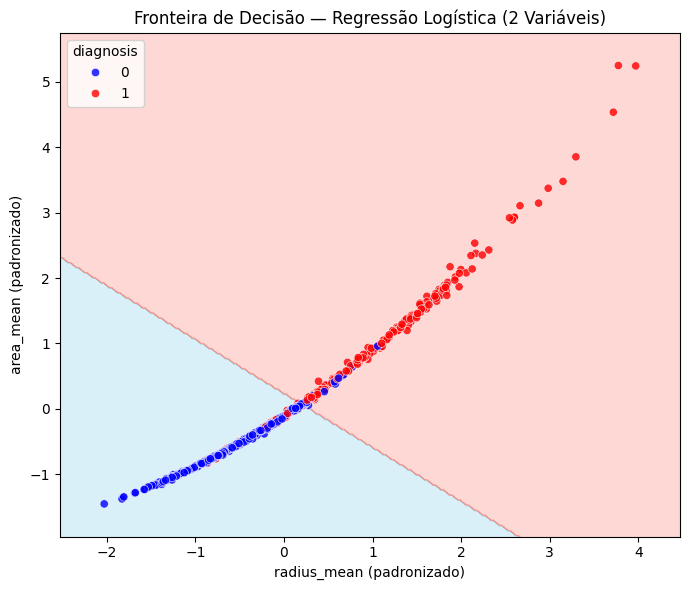

In [5]:
# c) Fronteira de decisão (usando 2 variáveis)
from matplotlib.colors import ListedColormap

# Selecionar duas variáveis para visualização
X2 = df[["radius_mean", "area_mean"]]
y2 = df["diagnosis"]

# Padronizar
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

# Treinar modelo 2D
model2 = LogisticRegression()
model2.fit(X2_scaled, y2)

# Criar grade para visualização
x_min, x_max = X2_scaled[:, 0].min() - 0.5, X2_scaled[:, 0].max() + 0.5
y_min, y_max = X2_scaled[:, 1].min() - 0.5, X2_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

Z = model2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(["skyblue", "salmon"]))
sns.scatterplot(
    x=X2_scaled[:,0],
    y=X2_scaled[:,1],
    hue=y2,
    palette={0:"blue", 1:"red"},
    alpha=0.8
)
plt.title("Fronteira de Decisão — Regressão Logística (2 Variáveis)")
plt.xlabel("radius_mean (padronizado)")
plt.ylabel("area_mean (padronizado)")
plt.tight_layout()
plt.show()
